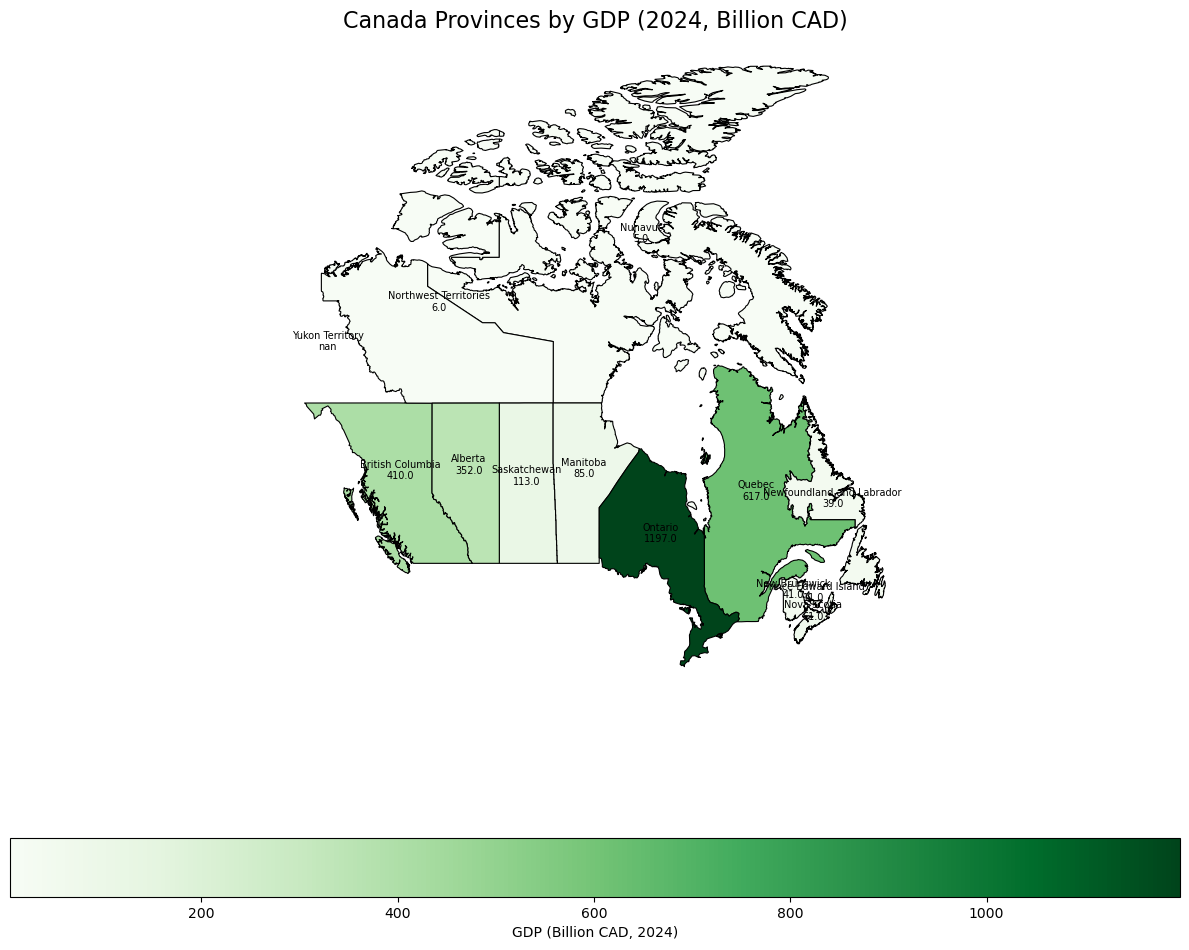

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load Canada provinces map
# -----------------------------
url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/canada.geojson"
canada = gpd.read_file(url)

# -----------------------------
# 2. GDP data (Billions CAD)
# -----------------------------
gdp_data = {
    "name": [
        "Ontario", "Quebec", "British Columbia", "Alberta",
        "Saskatchewan", "Manitoba", "Nova Scotia",
        "New Brunswick", "Newfoundland and Labrador",
        "Prince Edward Island", "Northwest Territories",
        "Nunavut", "Yukon"
    ],
    "gdp_billions_cad": [
        1197, 617, 410, 352,
        113, 85, 61,
        41, 39,
        11, 6,
        5, 4
    ]
}

df = pd.DataFrame(gdp_data)

# -----------------------------
# 3. Merge
# -----------------------------
merged = canada.merge(df, on="name", how="left")

# -----------------------------
# 4. Plot
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

merged.plot(
    column="gdp_billions_cad",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "GDP (Billion CAD, 2024)", "orientation": "horizontal"},
    ax=ax
)

# -----------------------------
# 5. Labels
# -----------------------------
for idx, row in merged.iterrows():
    if row["geometry"] is not None:
        centroid = row["geometry"].centroid
        ax.text(
            centroid.x,
            centroid.y,
            f"{row['name']}\n{row['gdp_billions_cad']}",
            fontsize=7,
            ha="center"
        )

# -----------------------------
# 6. Styling
# -----------------------------
ax.set_title("Canada Provinces by GDP (2024, Billion CAD)", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

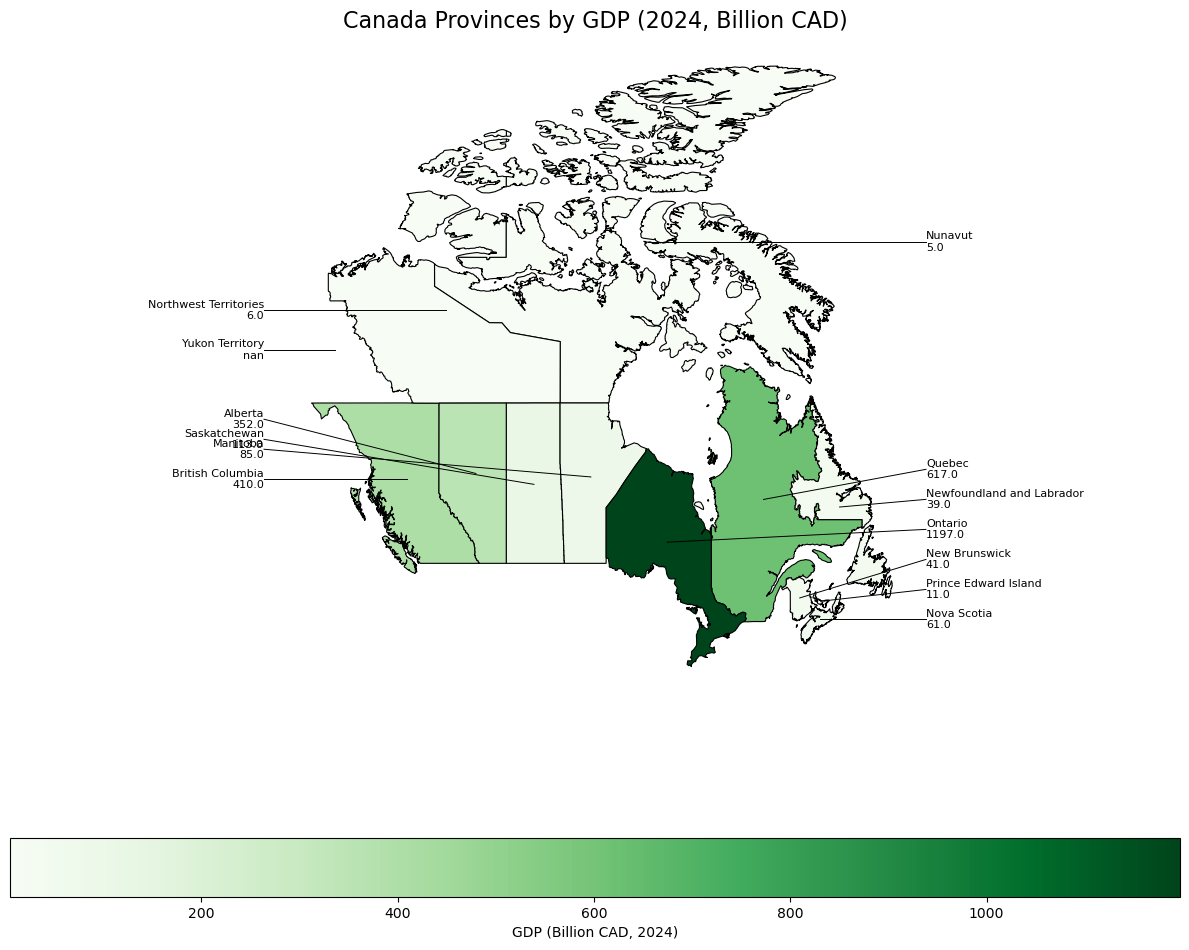

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load map
# -----------------------------
url = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/canada.geojson"
canada = gpd.read_file(url)

# -----------------------------
# 2. GDP data (2024, Billion CAD)
# -----------------------------
gdp_data = {
    "name": [
        "Ontario", "Quebec", "British Columbia", "Alberta",
        "Saskatchewan", "Manitoba", "Nova Scotia",
        "New Brunswick", "Newfoundland and Labrador",
        "Prince Edward Island", "Northwest Territories",
        "Nunavut", "Yukon"
    ],
    "gdp": [
        1197, 617, 410, 352,
        113, 85, 61,
        41, 39,
        11, 6,
        5, 4
    ]
}

df = pd.DataFrame(gdp_data)

# -----------------------------
# 3. Merge
# -----------------------------
merged = canada.merge(df, on="name", how="left")

# -----------------------------
# 4. Plot base map
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 10))

merged.plot(
    column="gdp",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "GDP (Billion CAD, 2024)", "orientation": "horizontal"},
    ax=ax
)

# -----------------------------
# 5. Get bounds (for spreading labels outward)
# -----------------------------
minx, miny, maxx, maxy = merged.total_bounds

# -----------------------------
# 6. Create external label positions
# -----------------------------
label_positions = {}

for idx, row in merged.iterrows():
    centroid = row.geometry.centroid
    x, y = centroid.x, centroid.y

    # Push labels outward depending on position
    if x < (minx + maxx) / 2:
        x_label = minx - 5   # left side
    else:
        x_label = maxx + 5   # right side

    y_label = y  # keep vertical alignment

    label_positions[row["name"]] = (x_label, y_label)

# -----------------------------
# 7. Spread labels vertically to avoid overlap
# -----------------------------
# Sort by y position
sorted_labels = sorted(label_positions.items(), key=lambda x: x[1][1])

min_gap = (maxy - miny) / 20  # spacing control

adjusted_positions = {}
last_y = None

for name, (x, y) in sorted_labels:
    if last_y is not None and abs(y - last_y) < min_gap:
        y = last_y + min_gap
    adjusted_positions[name] = (x, y)
    last_y = y

# -----------------------------
# 8. Draw lines + labels
# -----------------------------
for idx, row in merged.iterrows():
    name = row["name"]
    gdp = row["gdp"]

    centroid = row.geometry.centroid
    x0, y0 = centroid.x, centroid.y
    x1, y1 = adjusted_positions[name]

    # line
    ax.plot([x0, x1], [y0, y1], color="black", linewidth=0.7)

    # label
    ax.text(
        x1,
        y1,
        f"{name}\n{gdp}",
        fontsize=8,
        ha="left" if x1 > x0 else "right",
        va="center"
    )

# -----------------------------
# 9. Styling
# -----------------------------
ax.set_title("Canada Provinces by GDP (2024, Billion CAD)", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()